# 5, 6

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [10]:
X, y = make_classification(n_samples=2000,
                           n_features=10,
                           n_informative=5,
                           n_redundant=2,
                           n_classes=3,
                           n_clusters_per_class=1,
                           random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=1)

model = LogisticRegression()
model.fit(X_train, y_train)
from sklearn.base import is_classifier
print(is_classifier(model))  

True


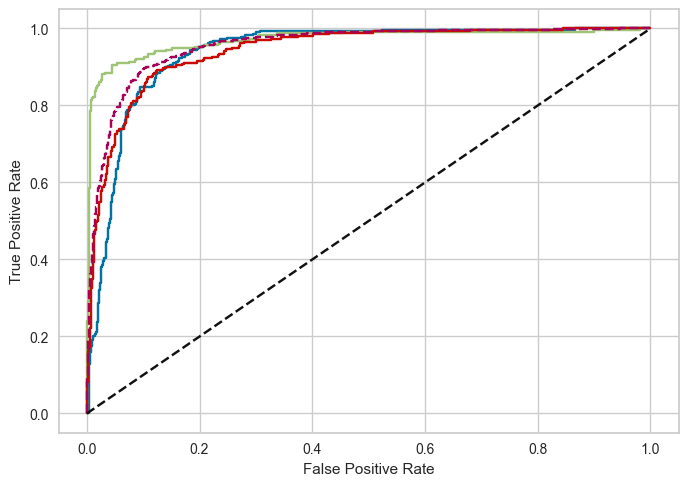

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict_proba(X_test)

fpr = dict(); tpr = dict(); roc_auc = dict()
for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'class {cls} (AUC={roc_auc[i]:.2f})')
plt.plot(fpr["micro"], tpr["micro"], '--',
         label=f'micro (AUC={roc_auc["micro"]:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


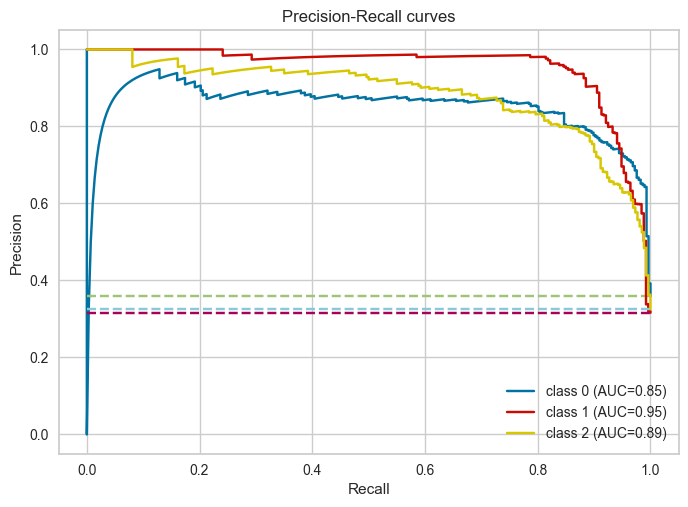

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       287
           1       0.90      0.90      0.90       253
           2       0.83      0.83      0.83       260

    accuracy                           0.85       800
   macro avg       0.86      0.86      0.86       800
weighted avg       0.86      0.85      0.86       800



In [13]:
from sklearn.metrics import precision_recall_curve, classification_report

precision = dict(); recall = dict(); pr_auc = dict()
plt.figure()
for i, cls in enumerate(classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    pr_auc[i] = auc(recall[i], precision[i])
    no_skill = y_test_bin[:, i].mean()
    plt.plot(recall[i], precision[i], label=f'class {cls} (AUC={pr_auc[i]:.2f})')
    plt.plot([0,1],[no_skill,no_skill],'--')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves')
plt.legend()
plt.show()

y_pred = model.predict(X_test)
print("Classification report:")
print(classification_report(y_test, y_pred))

In [14]:
#YELLOWBRICK DOESNt WORK IDK: THIS IS FROM THEIR DOCUMENTATION

import matplotlib.pyplot as plt

from yellowbrick.datasets import load_spam
from sklearn.linear_model import RidgeClassifier
from yellowbrick.classifier import PrecisionRecallCurve
from sklearn.model_selection import train_test_split as tts

# Load the dataset and split into train/test splits
X, y = load_spam()

X_train, X_test, y_train, y_test = tts(
    X, y, test_size=0.2, shuffle=True, random_state=0
)

# Create the visualizer, fit, score, and show it
viz = PrecisionRecallCurve(RidgeClassifier(random_state=0))
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

YellowbrickTypeError: This estimator is not a classifier; try a regression or clustering score visualizer instead!